# IPCA for US Firm Characteristics

Instrumented PCA (IPCA) tests whether characteristic-conditioned factor loadings forecast the
cross-section of monthly US firm returns. It is the linear characteristic-sorted latent-factor
baseline for this case study.

**Learning objectives**

- trace the train-only walk-forward fit of the characteristic-to-loading map;
- compare daily cross-sectional IC across raw, winsorized, and classification labels; and
- interpret HAC uncertainty without treating a positive variant as evidence for the primary task.

**Book reference:** *Chapter 14, Section 14.5*, on characteristic-conditioned latent factors.
**Prerequisites:** the corrected US firm features, labels, and ten temporal splits.

Each fold fits the loading map and factor-premium history on its training months, then forecasts
its validation months without using validation returns during fitting. The sealed 2016 holdout is
absent from training, cache identity, and evaluation. The classification variant is evaluated
against the continuous one-month return from which its class label was derived.

The provider panel retains complete characteristic cases and exposes anonymous split-scoped firm
identities, so the original universe construction cannot be independently reconstructed. We
report mean monthly cross-sectional information coefficient (IC) with a Newey-West HAC interval.
Cross-model and strategy selection belong in `10_model_analysis` and later notebooks.

In [1]:
"""US firm characteristics IPCA case-study run via the shared latent-factor library path."""

import contextlib
import io
import sqlite3
import warnings
from unittest.mock import Mock, patch

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import utils.style  # noqa: F401 - activates the ML4T visual style
from case_studies.utils.latent_factors import cv as latent_cv
from case_studies.utils.latent_factors.case_study import (
    configured_models,
    load_case_study_context,
    run_case_study_model,
    run_case_study_variants,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
N_FACTORS = 5
N_EPOCHS = 50
USE_CACHE = True
FORCE_RETRAIN = False
MAX_FOLDS = 0
MAX_VARIANT_LABELS = -1
RUN_VARIANTS = True
USE_MACRO = False
MODEL_NAME = "ipca"
FOLD_WORKERS = 4

In [3]:
context = load_case_study_context(
    CASE_STUDY_ID,
    primary_label=PRIMARY_LABEL,
    max_symbols=MAX_SYMBOLS,
    max_folds=MAX_FOLDS,
    max_variant_labels=MAX_VARIANT_LABELS,
    use_macro=USE_MACRO,
)
available_models = configured_models(context)
if MODEL_NAME not in available_models:
    raise ValueError(f"{MODEL_NAME!r} is not configured for {CASE_STUDY_ID}")

print(f"Case study: {CASE_STUDY_ID}")
print(f"Model: {MODEL_NAME}")
print(f"Primary label: {context.primary_label}")
print(f"Variant labels: {context.variant_labels}")
print(f"Dataset rows: {len(context.dataset):,}")
print(f"Features: {len(context.feature_names)}")
print(f"Splits: {len(context.splits)}")

Case study: us_firm_characteristics
Model: ipca
Primary label: fwd_ret_1m
Variant labels: ['fwd_ret_1m_win', 'fwd_class_1m']
Dataset rows: 804,530
Features: 57
Splits: 10


## Walk-forward cross-validation (primary label)

The production fit used four bounded CPU workers because IPCA has no GPU implementation. During
publication replay, a fitting sentinel makes any cache miss fail before training or registry
mutation can begin.

In [4]:
fit_guard = Mock(side_effect=RuntimeError("IPCA fitting is forbidden during sign-off"))
cache_output = io.StringIO()
with (
    patch.dict(latent_cv._MODEL_RUNNERS, {MODEL_NAME: fit_guard}),
    contextlib.redirect_stdout(cache_output),
):
    result = run_case_study_model(
        context,
        model_name=MODEL_NAME,
        notebook="08a_ipca",
        n_factors=N_FACTORS,
        n_epochs=N_EPOCHS,
        use_cache=USE_CACHE,
        force_retrain=FORCE_RETRAIN,
        fold_workers=FOLD_WORKERS,
    )

assert fit_guard.call_count == 0
assert "loaded registry" in cache_output.getvalue()
print("Cache-only primary execution passed: registered predictions loaded; fit calls = 0.")
print(result["model_results"])
print(result["fold_metrics"][MODEL_NAME])

Cache-only primary execution passed: registered predictions loaded; fit calls = 0.
[{'model_name': 'ipca', 'mean_ic': -0.0297, 'best_epoch': 0, 'n_folds': 10, 'elapsed_s': 0.0, 'started_at': None}]
shape: (10, 3)
┌───────┬─────────┬───────────┐
│ epoch ┆ fold_id ┆ ic_mean   │
│ ---   ┆ ---     ┆ ---       │
│ i64   ┆ i64     ┆ f64       │
╞═══════╪═════════╪═══════════╡
│ 0     ┆ 0       ┆ -0.052376 │
│ 0     ┆ 1       ┆ -0.073343 │
│ 0     ┆ 2       ┆ -0.014426 │
│ 0     ┆ 3       ┆ -0.039814 │
│ 0     ┆ 4       ┆ -0.062651 │
│ 0     ┆ 5       ┆ -0.015057 │
│ 0     ┆ 6       ┆ 0.024303  │
│ 0     ┆ 7       ┆ 0.017407  │
│ 0     ┆ 8       ┆ -0.022801 │
│ 0     ┆ 9       ┆ -0.057857 │
└───────┴─────────┴───────────┘


## Variant Labels

The same estimator is scored against the winsorized return and classification variants. These
remain modeling diagnostics; the primary raw-return label drives the downstream strategy sweep.

In [5]:
variant_results = {}
if RUN_VARIANTS and context.variant_labels:
    variant_fit_guard = Mock(side_effect=RuntimeError("IPCA fitting is forbidden during sign-off"))
    variant_cache_output = io.StringIO()
    with (
        patch.dict(latent_cv._MODEL_RUNNERS, {MODEL_NAME: variant_fit_guard}),
        contextlib.redirect_stdout(variant_cache_output),
    ):
        variant_results = run_case_study_variants(
            context,
            model_name=MODEL_NAME,
            notebook="08a_ipca",
            n_factors=N_FACTORS,
            n_epochs=N_EPOCHS,
            use_cache=USE_CACHE,
            force_retrain=FORCE_RETRAIN,
            fold_workers=FOLD_WORKERS,
        )
    assert variant_fit_guard.call_count == 0
    assert variant_cache_output.getvalue().count("loaded registry") == len(variant_results)
    print("Cache-only variant execution passed: registered predictions loaded; fit calls = 0.")
    for label, variant_result in variant_results.items():
        print(label, variant_result["model_results"])

Cache-only variant execution passed: registered predictions loaded; fit calls = 0.
fwd_ret_1m_win [{'model_name': 'ipca', 'mean_ic': 0.0188, 'best_epoch': 0, 'n_folds': 10, 'elapsed_s': 0.0, 'started_at': None}]
fwd_class_1m [{'model_name': 'ipca', 'mean_ic': 0.071, 'best_epoch': 0, 'n_folds': 10, 'elapsed_s': 0.0, 'started_at': None}]


## Validation significance

The registry computes rank IC separately for every validation month, averages the sorted monthly
series, and applies Newey-West HAC inference. IPCA emits one reporting checkpoint per label, so
the table and chart identify the exact current-input row for each task.

In [6]:
def significance_summary(case_study_id: str) -> pl.DataFrame:
    """Return current IPCA validation IC and matching HAC intervals."""
    query = """
        SELECT t.label, ps.checkpoint_value AS epoch, pm.ic_mean_daily AS ic_mean,
               pm.ic_t_hac, pm.ic_p_hac, pm.ic_ci_lo, pm.ic_ci_hi, pm.ic_n_days
        FROM training_runs t
        JOIN prediction_sets ps USING(training_hash)
        JOIN prediction_metrics pm USING(prediction_hash)
        WHERE t.family='latent_factors' AND t.config_name='ipca'
          AND ps.split='validation'
        ORDER BY t.label
    """
    registry_path = get_case_study_dir(case_study_id) / "run_log/registry.db"
    with sqlite3.connect(registry_path) as connection:
        cursor = connection.execute(query)
        columns = [description[0] for description in cursor.description]
        rows = cursor.fetchall()
    frame = pl.DataFrame(rows, schema=columns, orient="row")
    if frame.height != 3 or frame["label"].n_unique() != 3:
        raise RuntimeError("Expected one current IPCA validation row for each of three labels")
    return frame.with_columns(
        pl.col("ic_mean").round(4),
        pl.col("ic_t_hac").round(2).alias("hac_t"),
        pl.col("ic_p_hac").round(3).alias("hac_p"),
        pl.col("ic_ci_lo").round(4).alias("ci_lo"),
        pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    ).select("label", "epoch", "ic_mean", "hac_t", "hac_p", "ci_lo", "ci_hi", "ic_n_days")

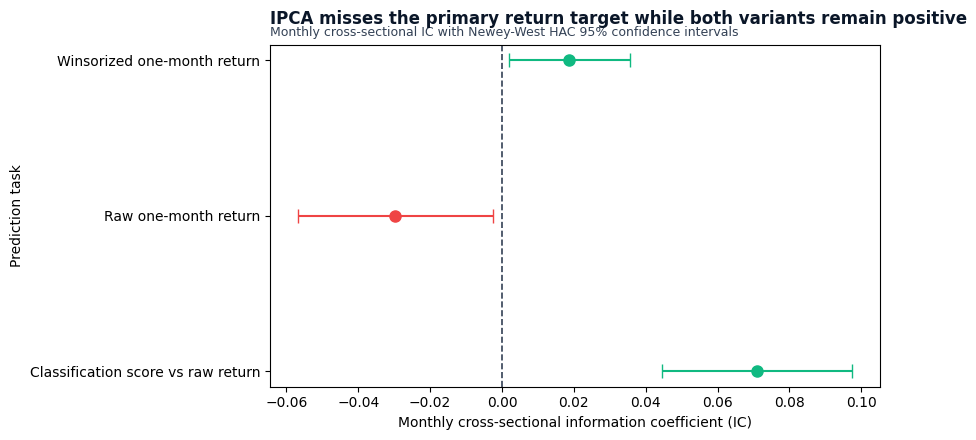

label,epoch,ic_mean,hac_t,hac_p,ci_lo,ci_hi,ic_n_days
str,i64,f64,f64,f64,f64,f64,f64
"""fwd_class_1m""",0,0.071,5.31,0.0,0.0445,0.0975,110.0
"""fwd_ret_1m""",0,-0.0297,-2.16,0.033,-0.0569,-0.0024,110.0
"""fwd_ret_1m_win""",0,0.0188,2.23,0.028,0.0021,0.0355,110.0


In [7]:
significance = significance_summary(CASE_STUDY_ID)
label_names = {
    "fwd_ret_1m": "Raw one-month return",
    "fwd_ret_1m_win": "Winsorized one-month return",
    "fwd_class_1m": "Classification score vs raw return",
}
plot_data = significance.with_columns(
    pl.col("label").replace(label_names).alias("display_label")
).sort("label")

fig, ax = plt.subplots(figsize=(9, 4.5))
for row_idx, row in enumerate(plot_data.iter_rows(named=True)):
    point = row["ic_mean"]
    if row["ci_lo"] > 0:
        color = COLORS["positive"]
    elif row["ci_hi"] < 0:
        color = COLORS["negative"]
    else:
        color = COLORS["blue"]
    ax.errorbar(
        point,
        row_idx,
        xerr=np.array([[point - row["ci_lo"]], [row["ci_hi"] - point]]),
        fmt="o",
        color=color,
        capsize=5,
        markersize=8,
    )

ax.axvline(0, color=COLORS["neutral"], linewidth=1.2, linestyle="--")
ax.set_yticks(range(plot_data.height), plot_data["display_label"].to_list())
ax.set_xlabel("Monthly cross-sectional information coefficient (IC)")
ax.set_ylabel("Prediction task")
add_message_title(
    ax,
    "IPCA misses the primary return target while both variants remain positive",
    subtitle="Monthly cross-sectional IC with Newey-West HAC 95% confidence intervals",
)
fig.tight_layout()
plt.show()

significance

## Takeaway

IPCA's primary raw-return IC is **-0.0297** across 110 validation months (HAC *t* -2.16, 95% CI
[-0.0569, -0.0024]), so the characteristic-conditioned linear factor model fails the primary
forecasting task. The winsorized target is mildly positive at **+0.0188** (95% CI
[+0.0021, +0.0355]), while the classification score reaches **+0.0710** against raw returns (95%
CI [+0.0445, +0.0975]). These variants diagnose target sensitivity; they do not replace the
primary target or trigger a new strategy sweep. `10_model_analysis` compares IPCA with the stronger
predictive families.